# Eddy detection

<div class="alert alert-block alert-info">
⚠️ Code and documentations obtained and edited from Claude.ai.
</div>

Uses the _Okubo-Weiss_ (OW) parameter as a proxy for SSH,
from a velocity field only (no SSH/SLA required).

The strategy:
  1. Load a NetCDF file containing U and V velocity components.
  2. Compute the Okubo-Weiss parameter from U and V.
  3. Negate OW so that eddy cores (rotation-dominated, OW < 0) become
     local maxima — matching the convention py-eddy-tracker expects for
     anticyclonic/cyclonic detection via closed contours.
  4. Apply a high-pass filter the negated OW field to remove large-scale structure.
  5. Run `eddy_identification()` on the negated OW field.
  6. Plot results.

## Notes


* The OW parameter is:  OW = Sn² + Ss² − ω²
      Sn = ∂u/∂x − ∂v/∂y   (normal strain)
      Ss = ∂v/∂x + ∂u/∂y   (shear strain)
      ω  = ∂v/∂x − ∂u/∂y   (vorticity)
  Eddy cores are where rotation dominates strain, i.e. OW < 0.
  We feed −OW to py-eddy-tracker so that eddy cores are local maxima,
  which is the same convention as SSH highs/lows.

* The amplitude and speed values reported by py-eddy-tracker will be in
  units of OW (s⁻²), not metres — they are still useful for relative
  comparison but have no direct physical meaning as SSH amplitudes.

* The filter wavelength (FILTER_KM) should be chosen to match the scales
  you want to resolve (typically 200–700 km for mesoscale eddies).

* `eddy_identification()` needs U and V to compute average speed around each
  candidate contour (uavg). Pass the original U and V variable names.

In [ ]:
from datetime import datetime
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
from py_eddy_tracker.dataset.grid import RegularGridDataset
import cartopy.crs as ccrs
import matplotlib as mpl
import netCDF4

### Matplotlib configuration

In [56]:
mpl.rc('image', cmap='RdBu_r')
mpl.rcParams['pcolor.shading'] = 'auto'
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams['savefig.bbox'] = 'tight'

myproj = ccrs.Mercator()

## Data
Data files obtained from https://zenodo.org/records/18860454.    
It is assumed the archived is extracted in `../data`.

In [58]:
datadir = "../data/CoastalCurrents_dataset/dataset_DIVA"
outputdir = "../results/"
figdir = "../figures"

if not(os.path.exists(outputdir)):
    os.mkdir(outputdir)
if not(os.path.exists(figdir)):
    os.mkdir(figdir)
    
datafilelist = sorted(glob.glob(os.path.join(datadir, "*.nc")))
datafilelist

['../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2013.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2014.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2015.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2016.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2017.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2018.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2019.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2020.nc',
 '../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2021.nc']

### Set variable names

In [3]:
LON_NAME    = "longitude"              
LAT_NAME    = "latitude"             
U_NAME      = "u_velocity"                      
V_NAME      = "v_velocity"                      

# Date of the snapshot (used for metadata in the output eddy objects)
DATE = datetime(2013, 1, 1)

### Eddy detection parameters

In [4]:
# High-pass filter cutoff wavelength in km.
# Signals larger than this are removed so that only mesoscale features remain.
# Typical range: 200 – 700 km.
FILTER_KM = 300

# Step between consecutive OW isolines used during contour tracing.
# Smaller values → finer detection but slower. Units: same as −OW (s⁻²).
# A value around 1e-12 is a reasonable starting point; tune to your data.
ISOLINE_STEP = 1e-12

# Eddy size constraints (in grid pixels)
PIXEL_LIMIT = (5, 2000)   # (min, max) pixels inside the speed contour

# Maximum acceptable shape error (%) — higher = allow more irregular shapes
SHAPE_ERROR = 75
# =============================================================================

## Eddy detection
### Load the grid

In [5]:
g = RegularGridDataset(datafilelist[-1], LON_NAME, LAT_NAME)
g.variables_description["neg_ow"] = {
    "attrs": {"units": "m"},   # placeholder — overridden below
    "args": (), "kwargs": {}, "infos": {},
}

We assume pixel position of grid is centered for ../data/CoastalCurrents_dataset/dataset_DIVA/dataOBSDIVA_2021.nc


### Compute the Okubo-Weiss parameter from U and V

In [6]:
u_x = g.compute_stencil(g.grid(U_NAME))                        # ∂u/∂x
u_y = g.compute_stencil(g.grid(U_NAME), vertical=True)         # ∂u/∂y
v_x = g.compute_stencil(g.grid(V_NAME))                        # ∂v/∂x
v_y = g.compute_stencil(g.grid(V_NAME), vertical=True)         # ∂v/∂y

Sn = u_x - v_y          # normal strain
Ss = v_x + u_y          # shear strain
omega = v_x - u_y       # relative vorticity

ow = Sn**2 + Ss**2 - omega**2   # OW < 0 inside eddy cores

### Plot to check the gradients

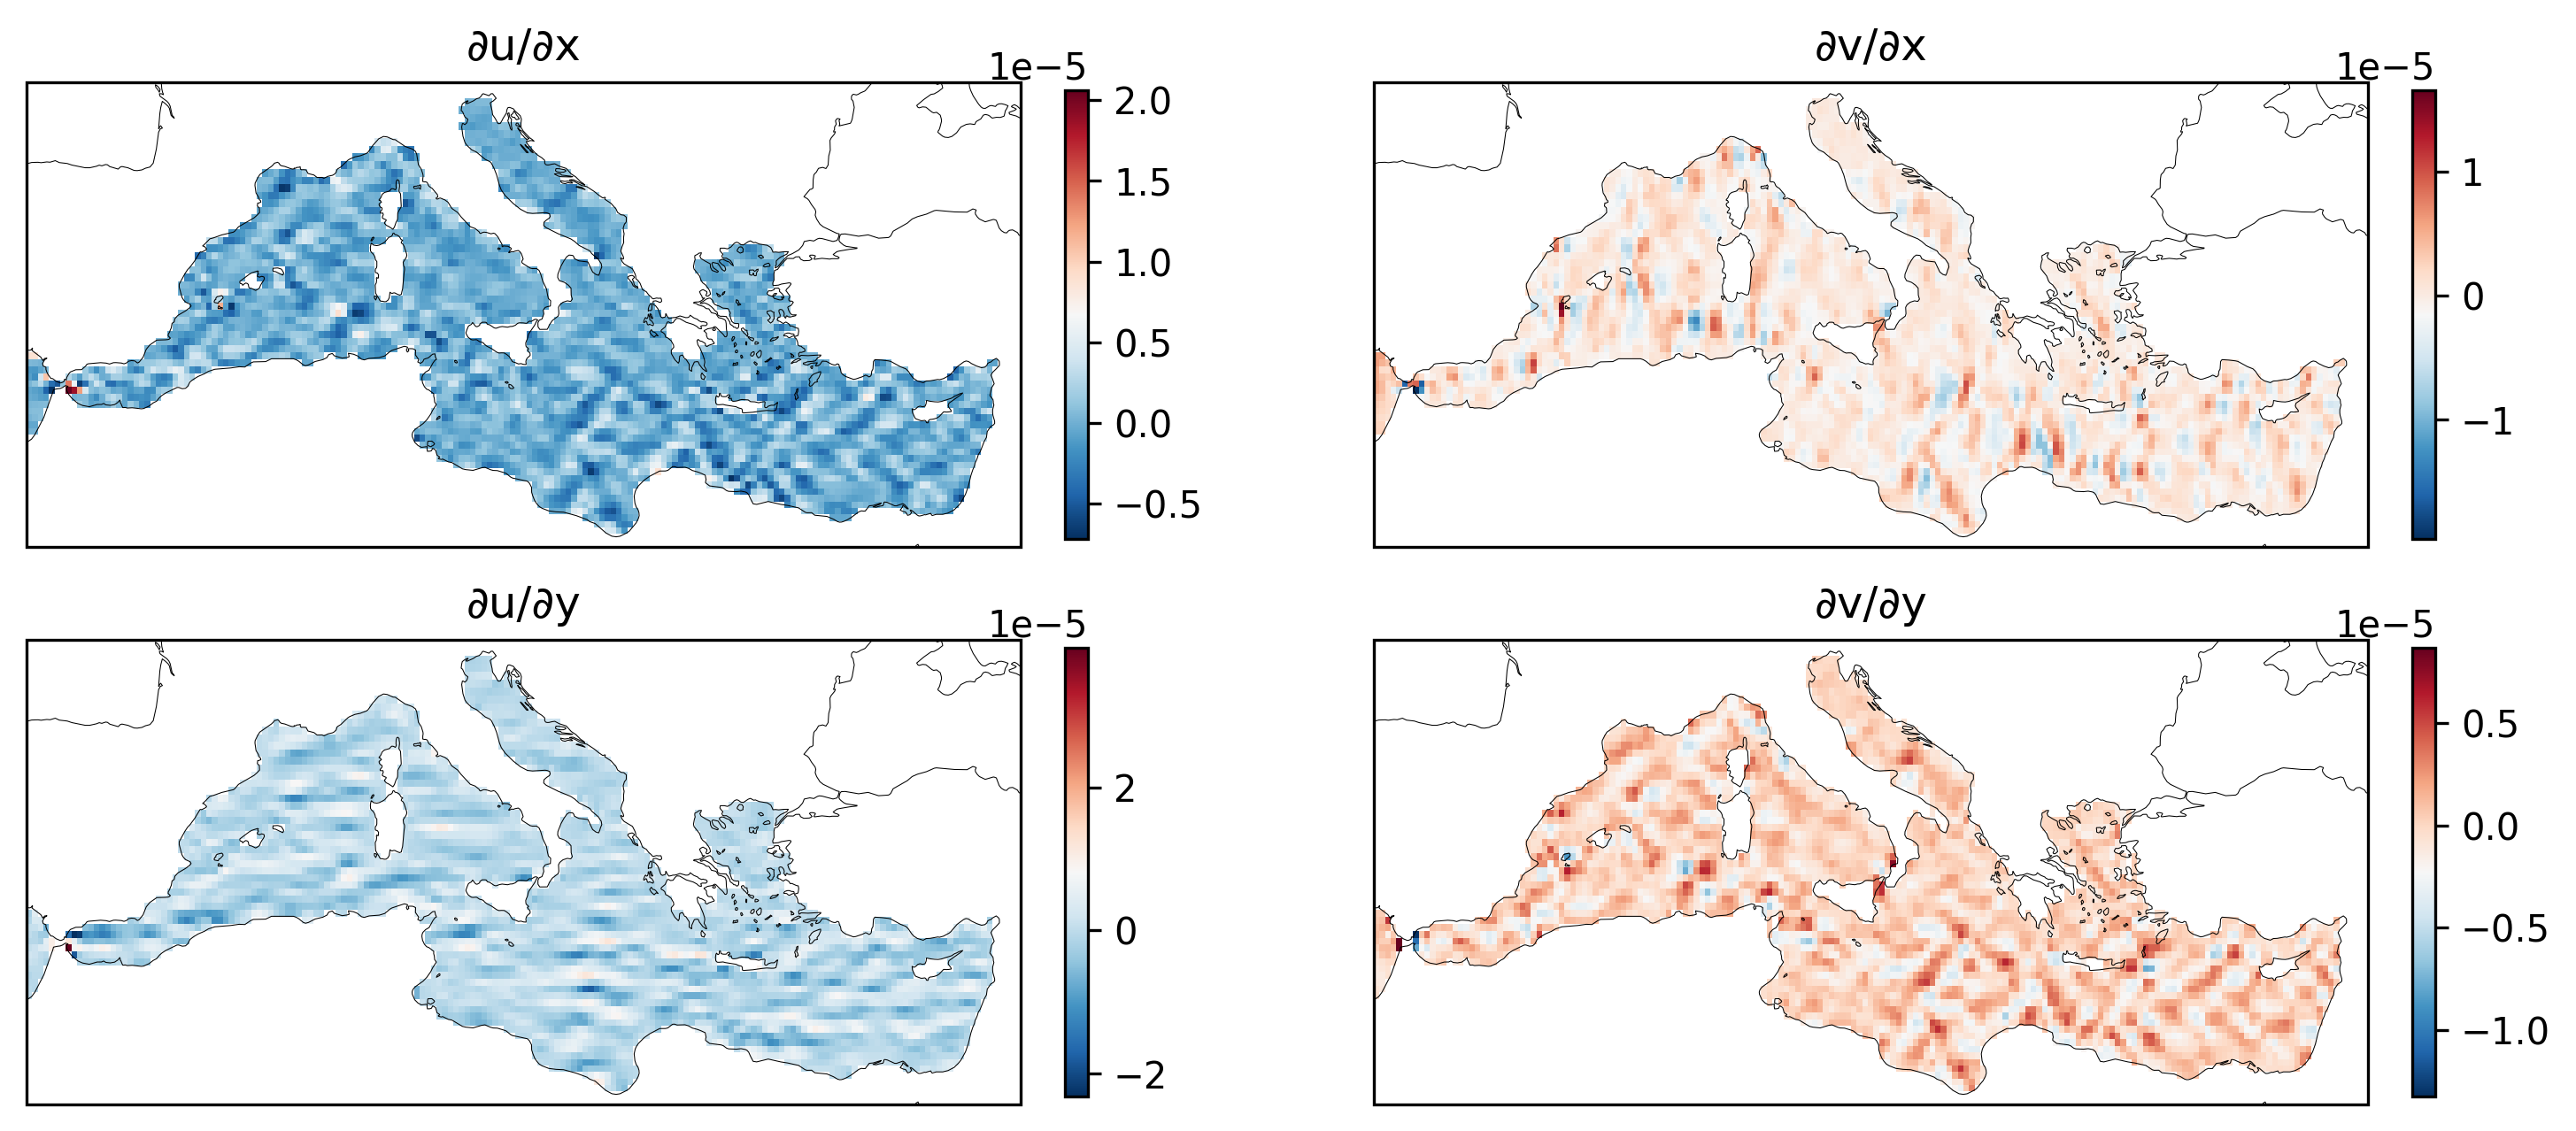

In [7]:
fig = plt.figure(figsize=(12, 5))
ax1 = plt.subplot(221, projection=myproj)
ax1.set_title("∂u/∂x")
ax1.coastlines(lw=.25)
pcm1 = ax1.pcolormesh(g.vars["longitude"], g.vars["latitude"], u_x.T, transform=ccrs.PlateCarree())
plt.colorbar(pcm1, fraction=0.02, pad=0.04)
ax2 = plt.subplot(222, projection=myproj)
ax2.set_title("∂v/∂x")
ax2.coastlines(lw=.25)
pcm2 = ax2.pcolormesh(g.vars["longitude"], g.vars["latitude"], v_x.T, transform=ccrs.PlateCarree())
plt.colorbar(pcm2, fraction=0.02, pad=0.04)
ax3 = plt.subplot(223, projection=myproj)
ax3.set_title("∂u/∂y")
ax3.coastlines(lw=.25)
pcm3 = ax3.pcolormesh(g.vars["longitude"], g.vars["latitude"], u_y.T, transform=ccrs.PlateCarree())
plt.colorbar(pcm3, fraction=0.02, pad=0.04)
ax4 = plt.subplot(224, projection=myproj)
ax4.set_title("∂v/∂y")
ax4.coastlines(lw=.25)
pcm4 = ax4.pcolormesh(g.vars["longitude"], g.vars["latitude"], v_y.T, transform=ccrs.PlateCarree())
plt.colorbar(pcm4, fraction=0.02, pad=0.04)

### Store Okubo-Weiss parameter 
And its negative in the grid so py-eddy-tracker can access them.

In [8]:
g.vars["ow"]     = np.ma.array(ow,  mask=np.isnan(ow))
g.vars["neg_ow"] = np.ma.array(-ow, mask=np.isnan(ow))

### Apply High-pass filter −OW to isolate mesoscale features

In [9]:
g.bessel_high_filter("neg_ow", FILTER_KM)

### Apply Algorithm

In [10]:
a, c = g.eddy_identification(
    "neg_ow",           # scalar height-like field
    U_NAME,             # eastward velocity  (for uavg computation)
    V_NAME,             # northward velocity (for uavg computation)
    DATE,
    ISOLINE_STEP,
    pixel_limit=PIXEL_LIMIT,
    shape_error=SHAPE_ERROR,
    # force_speed_unit and force_height_unit can be set here if py-eddy-tracker
    # complains about units; e.g.:
    # force_speed_unit="m/s",
    # force_height_unit="m",
)

print(f"Anticyclonic eddies detected: {len(a)}")
print(f"Cyclonic eddies detected:     {len(c)}")

/home/ctroupin/.virtualenvs/Eddy/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Anticyclonic eddies detected: 56
Cyclonic eddies detected:     58


## Plots
### Okubo-Weiss parameter

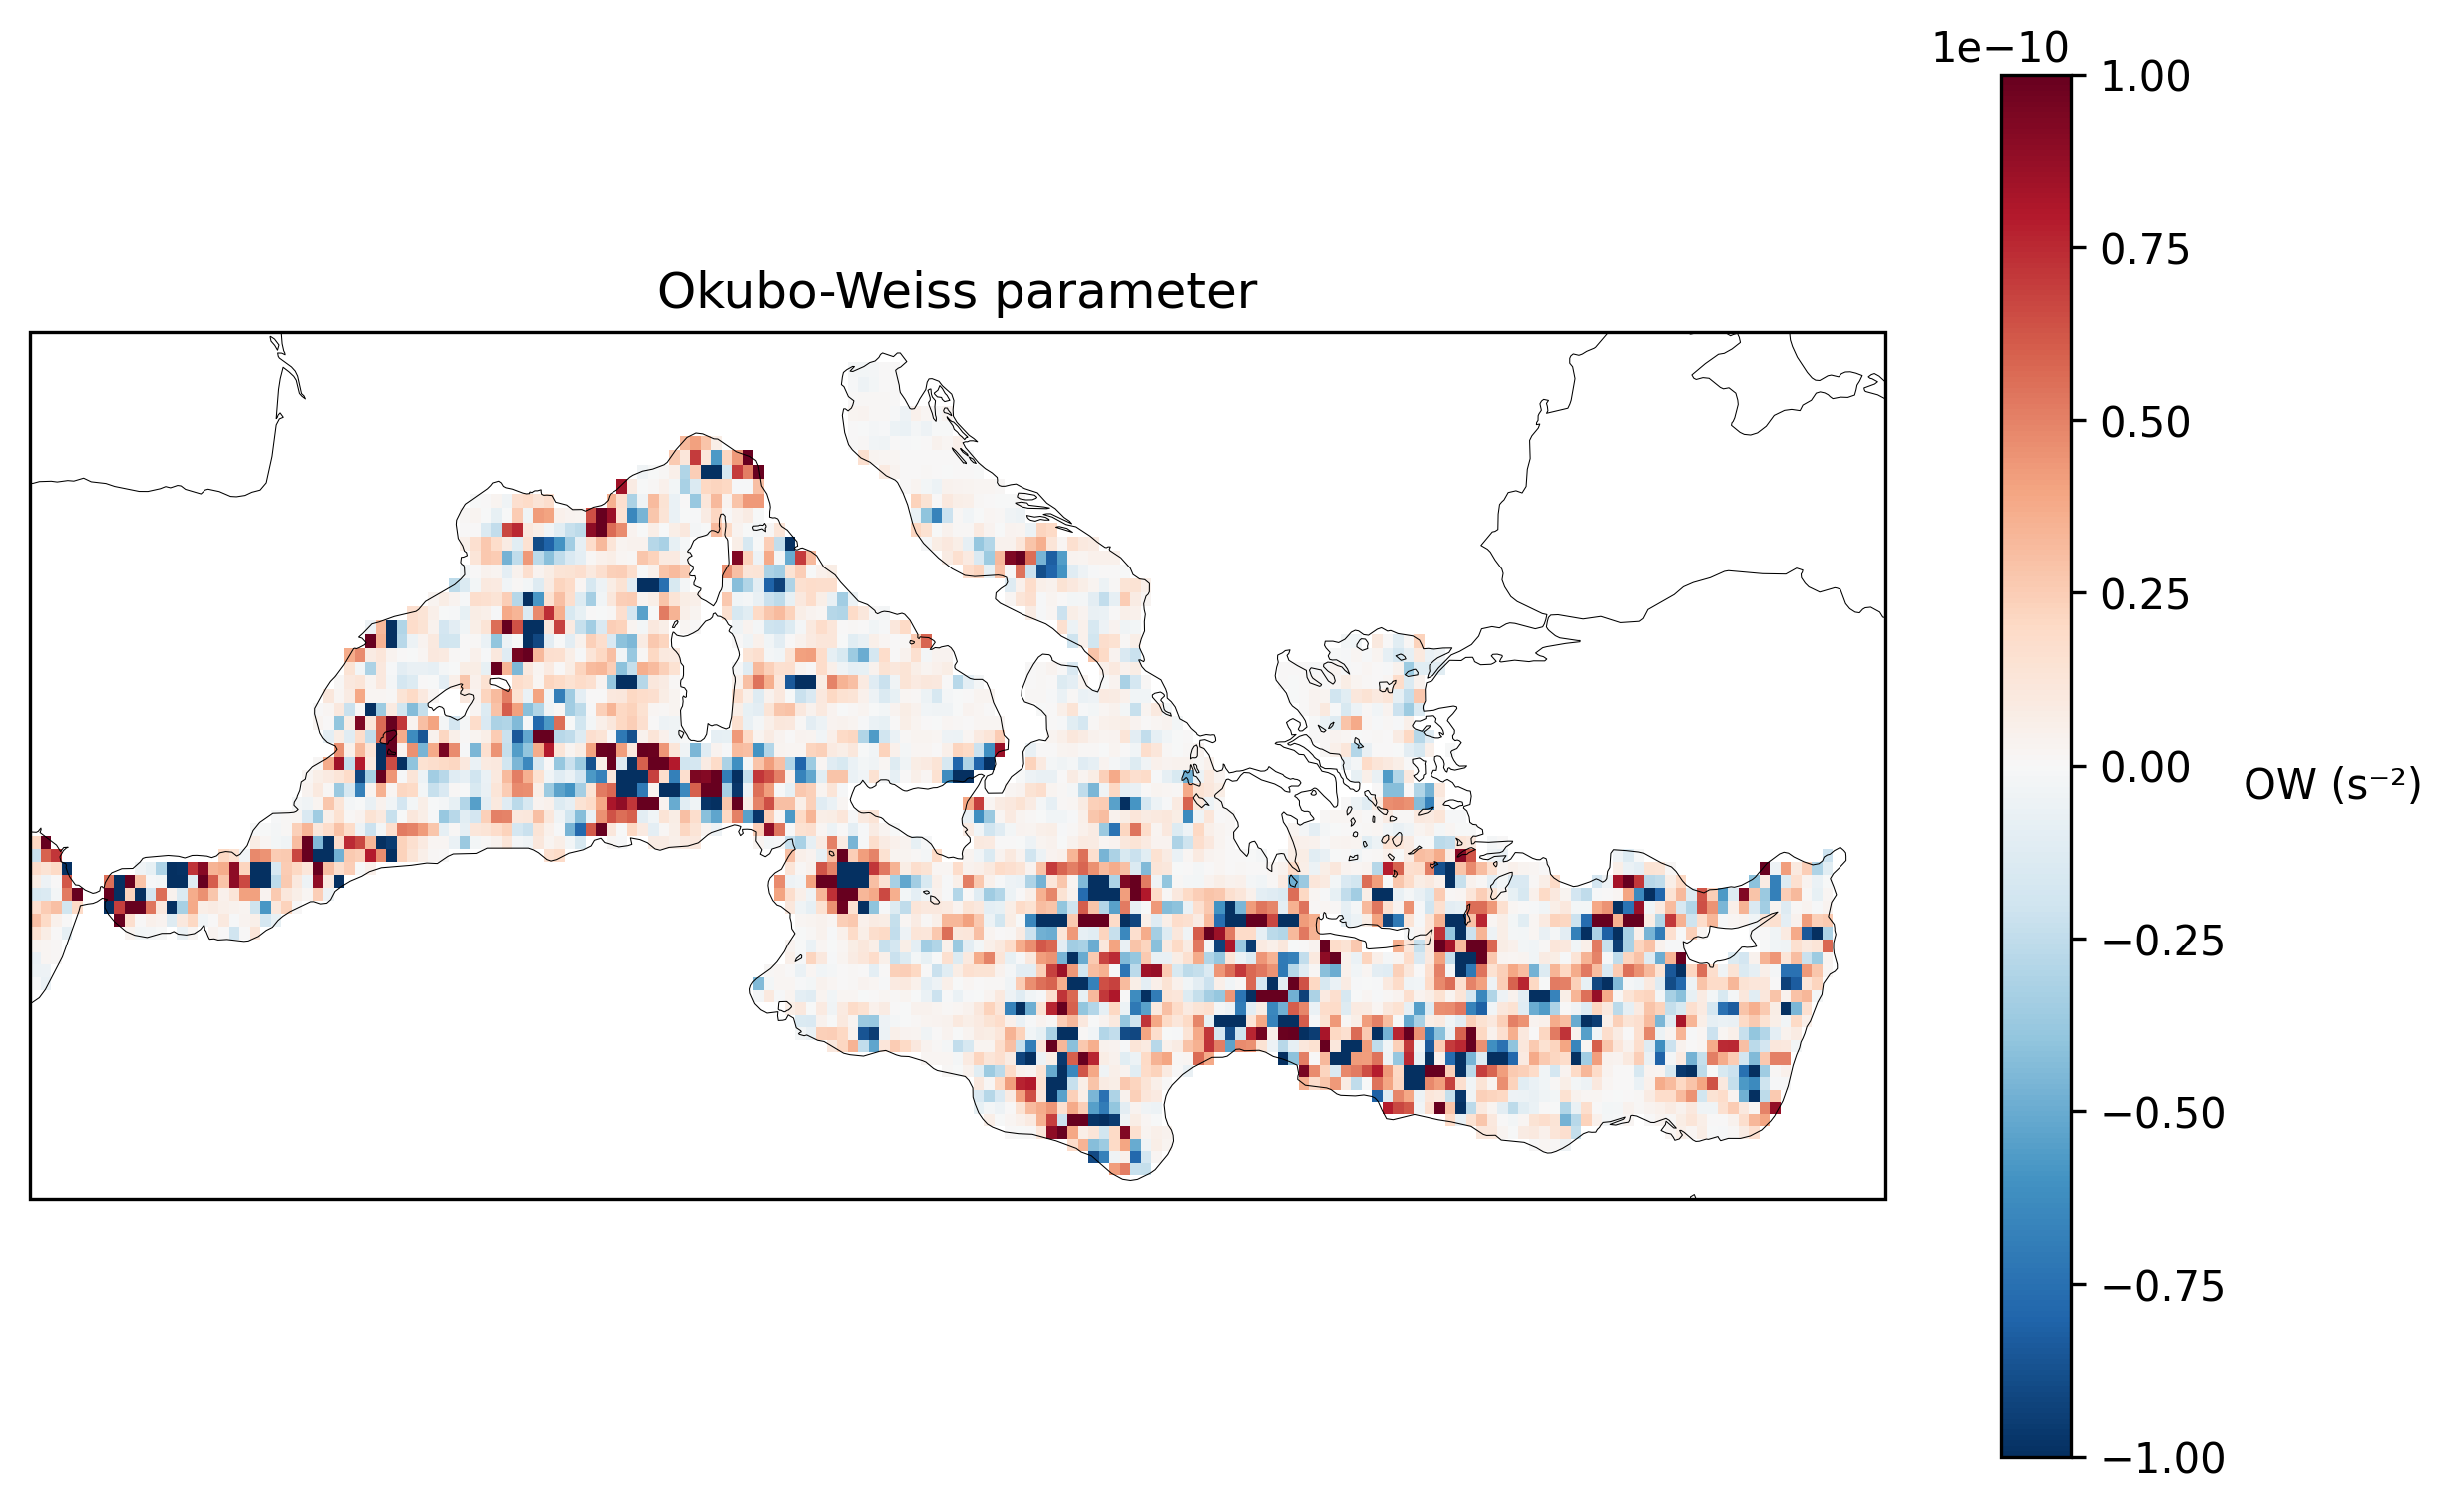

In [60]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection=myproj)
ax.coastlines(lw=.25)
lon, lat = g.x_c, g.y_c
pcm = ax.pcolormesh(
    lon, lat, g.vars["ow"].T,
    cmap="RdBu_r", vmin=-10e-11, vmax=10e-11, transform=ccrs.PlateCarree()
)
cb = plt.colorbar(pcm, ax=ax)
cb.set_label(label="OW (s⁻²)", rotation=0, ha="left")
ax.set_title("Okubo-Weiss parameter")
plt.savefig(os.path.join(figdir, "okubo_weiss.jpg"))
plt.show()

### Eddies

/home/ctroupin/.virtualenvs/Eddy/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/ctroupin/.virtualenvs/Eddy/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/ctroupin/.virtualenvs/Eddy/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/home/ctroupin/.virtualenvs/Eddy/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


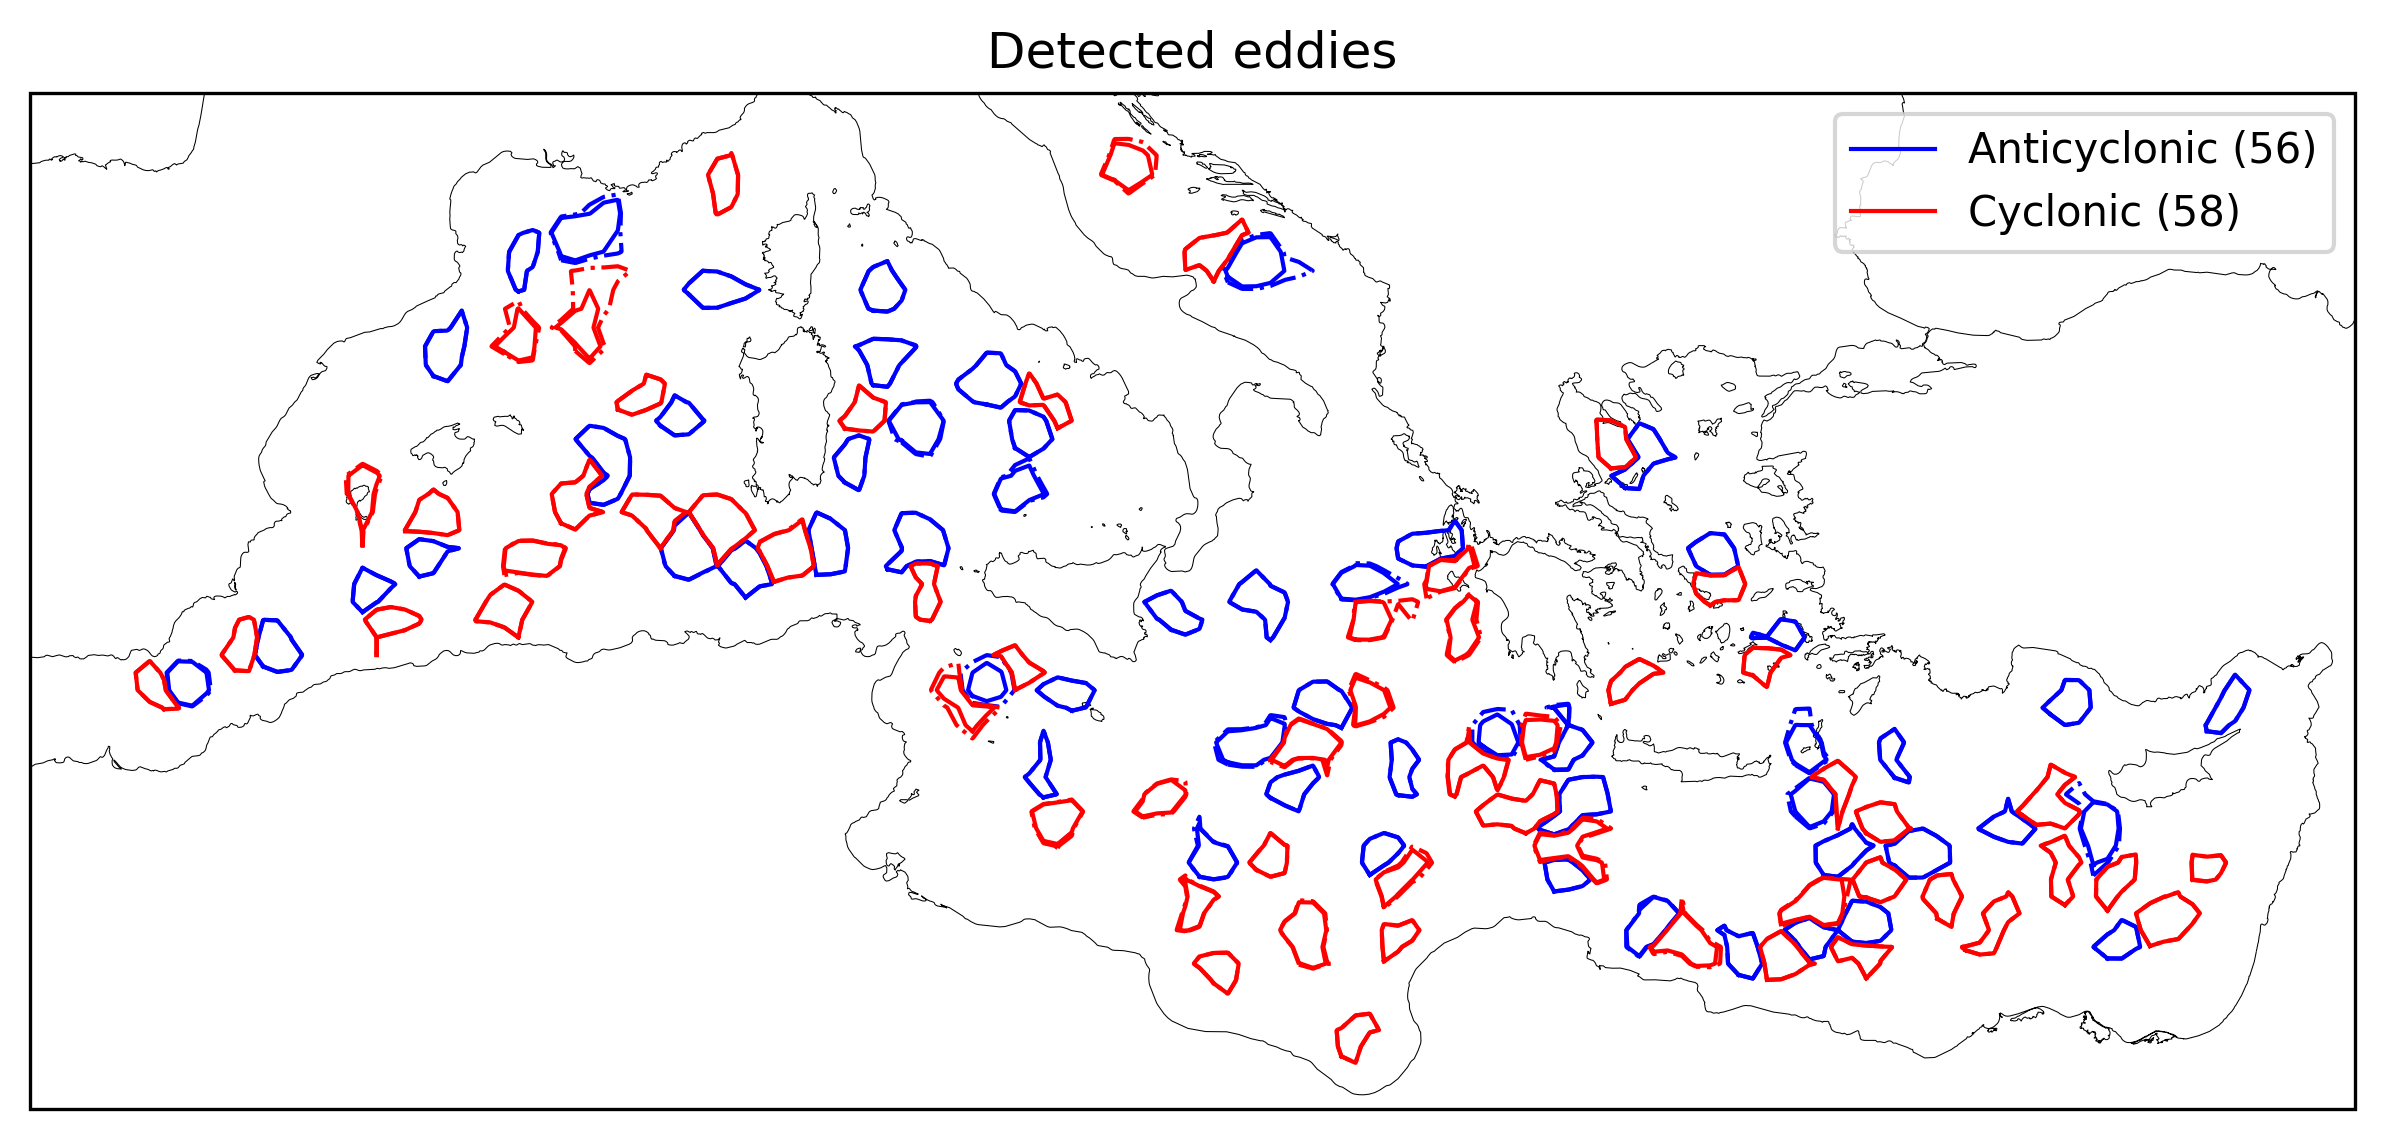

In [12]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection=myproj)
ax.coastlines(lw=.25)
# Display detected contours
a.display(ax, color="blue",  linewidth=1.0, label=f"Anticyclonic ({len(a)})", transform=ccrs.PlateCarree())
c.display(ax, color="red",   linewidth=1.0, label=f"Cyclonic ({len(c)})", transform=ccrs.PlateCarree())

ax.set_title("Detected eddies")
ax.legend(loc="upper right")
plt.savefig(os.path.join(figdir, "eddies.jpg"))
plt.show()

In [ ]:
llon, llat = np.meshgrid(g.grid(LON_NAME), g.grid(LAT_NAME))

### Compute velocity norm
Since there is a _hot_ pixel (where velocity is much higher than the rest of the cells), we set a maximal value (for plotting purposes).

In [51]:
velmax = 0.4
velnorm = np.sqrt(g.grid(U_NAME) * g.grid(U_NAME) + g.grid(V_NAME) * g.grid(V_NAME))
velnorm[velnorm >= velmax] = velmax

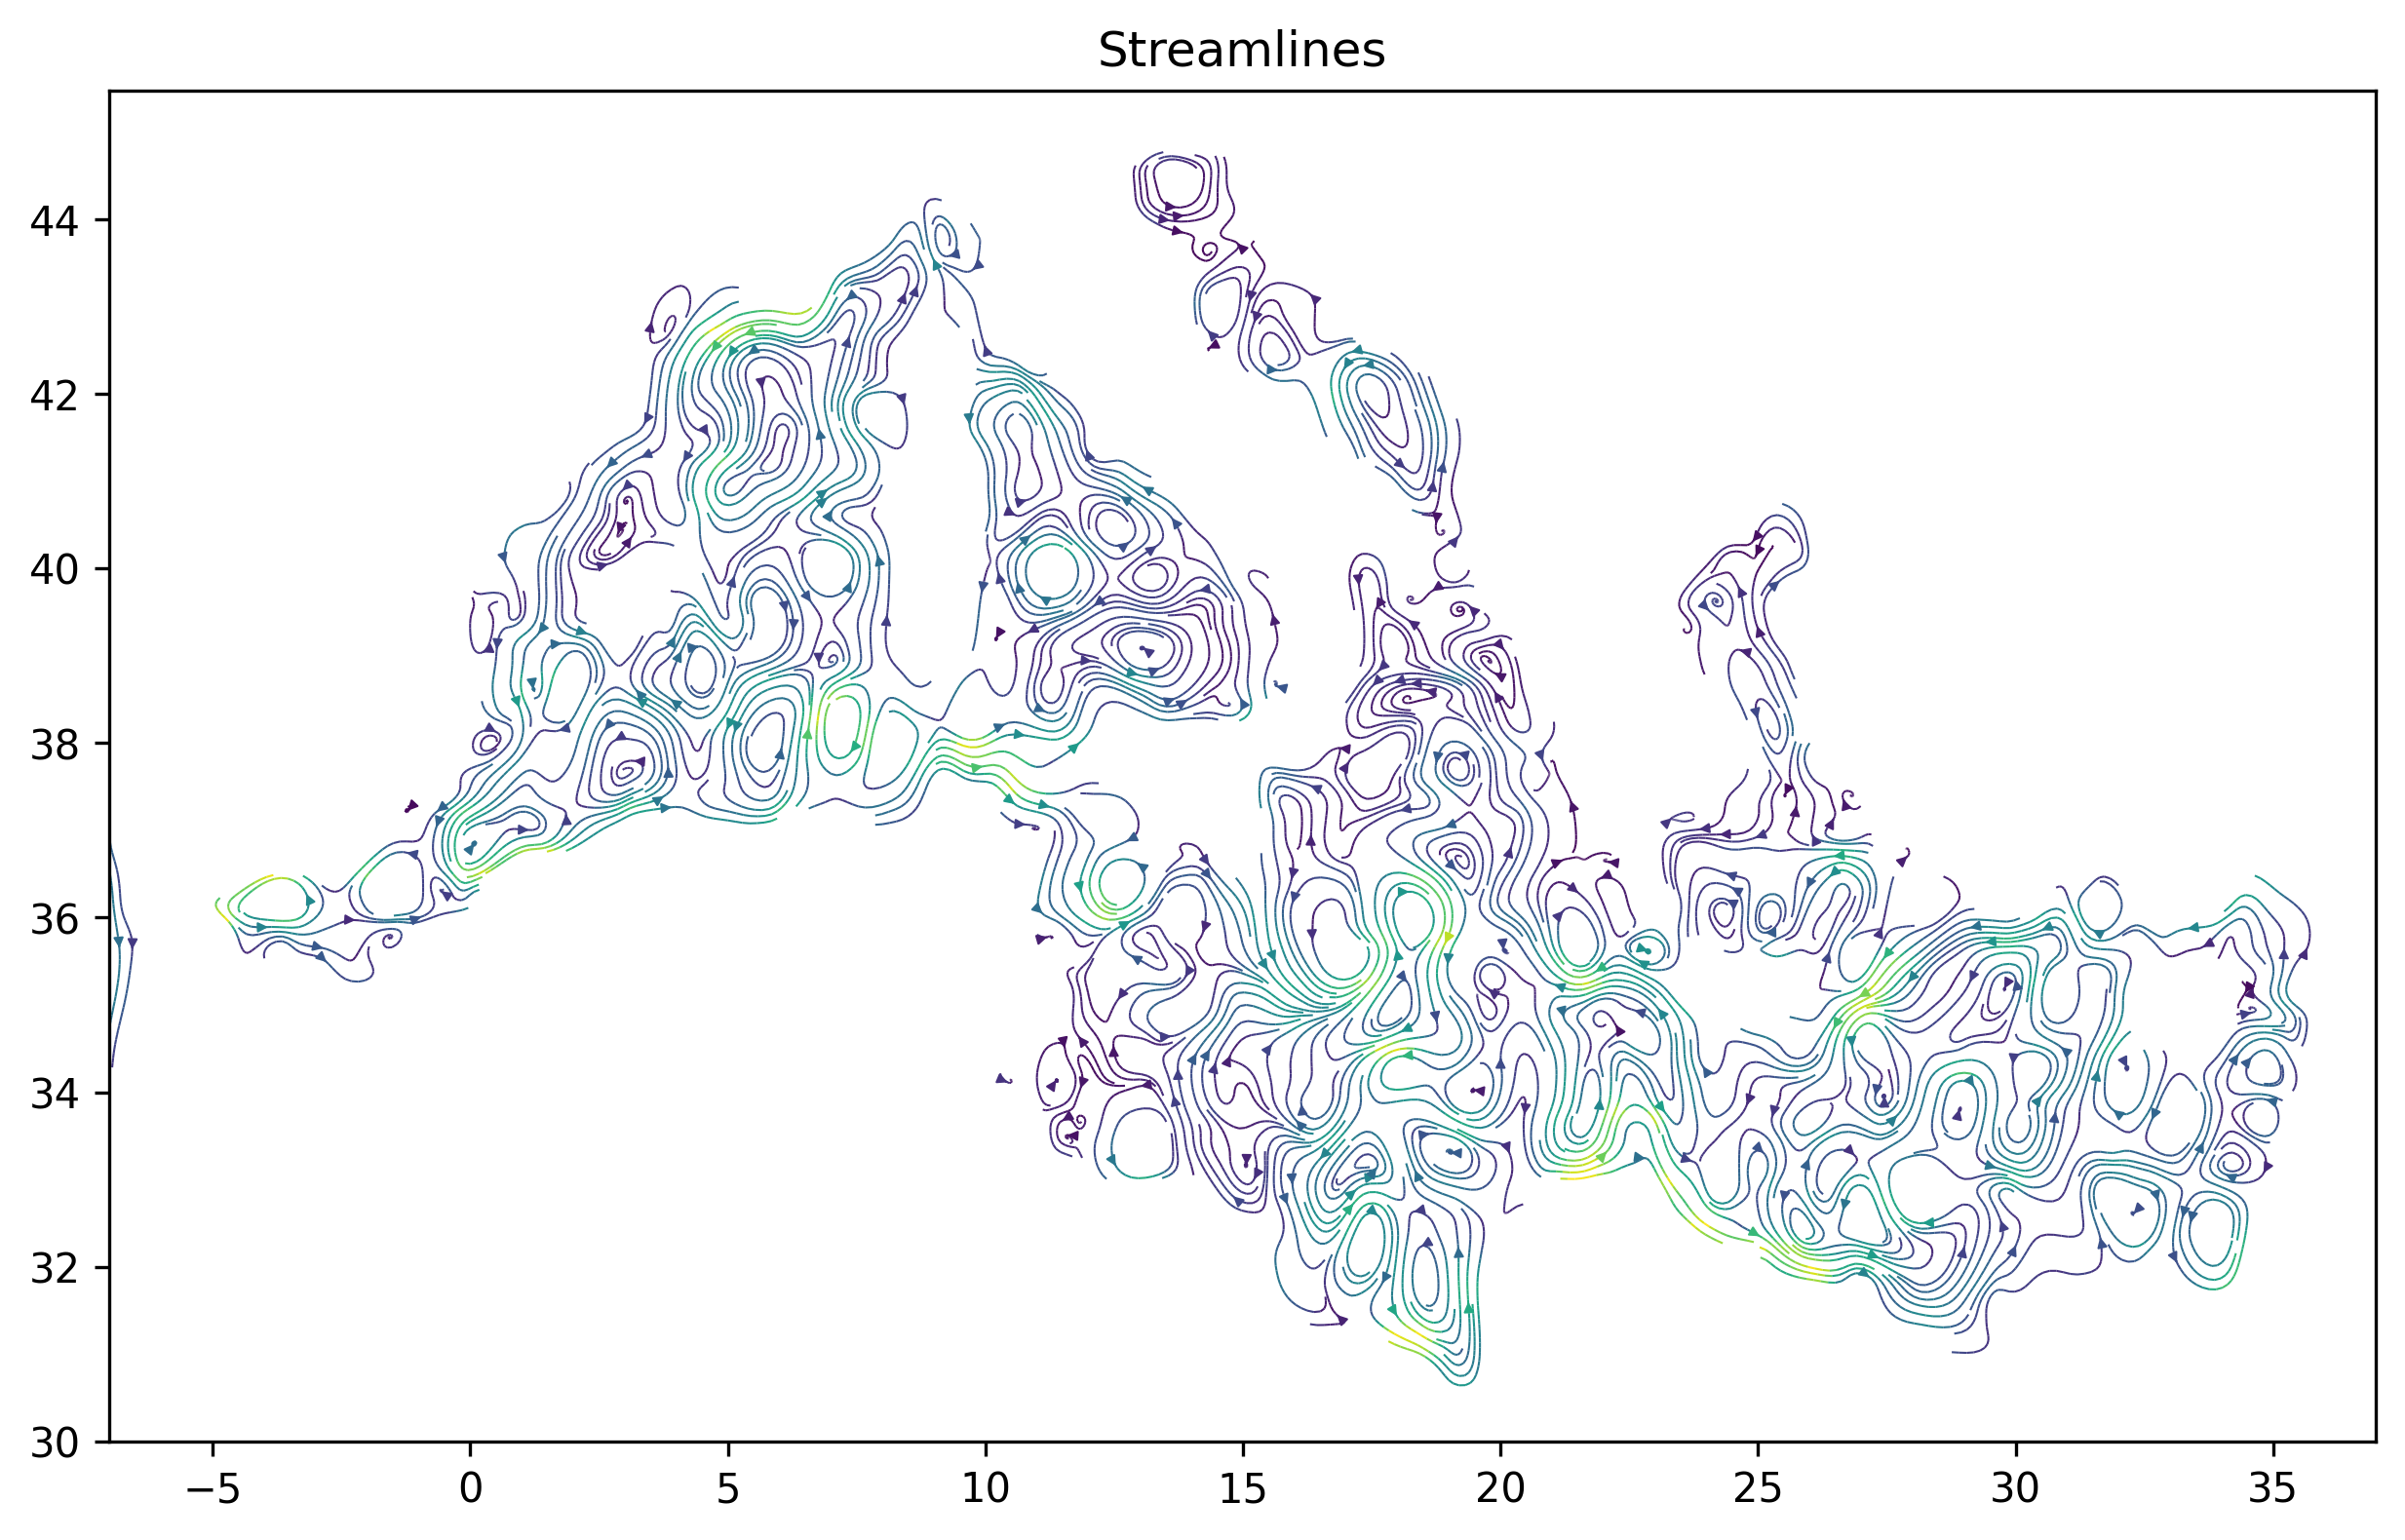

In [55]:
fig = plt.figure(figsize=(10, 6))
ax = plt.subplot(111)
ax.set_title("Streamlines")
stp = ax.streamplot(llon, llat, g.grid(U_NAME).T, g.grid(V_NAME).T, color=velnorm.T, density=10, 
              linewidth=0.5, arrowsize=0.5, cmap=plt.cm.viridis)
#cb = plt.colorbar(stp, extend="max")
# cb.set_label("m/s", rotation=0, ha="left")
plt.savefig(os.path.join(figdir, "streamlines.jpg"))
plt.show()

## Save eddy observations to NetCDF

In [59]:
with netCDF4.Dataset(os.path.join(outputdir, "Anticyclonic_OW.nc"), "w") as h:
    a.to_netcdf(h)
with netCDF4.Dataset(os.path.join(outputdir, "Cyclonic_OW.nc"), "w") as h:
    c.to_netcdf(h)